# **Perona–Malik — interactive demo (users)**

## Libraries

In [1]:
import numpy as np, matplotlib.pyplot as plt, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

from core.config import LayoutConfig, GlobalConfig, ImageProcessorConfig
from operators.image_operator import Operator
from operators.image_processor import ImageProcessor
from operators.image_io import ImageIO
from operators.metrics import PSNR
from algorithms.perona_malik import pm
from utils.nd_tools import show_plane  # helper for plane visualization
from utils.decorators import timer # helper for benchmarking

## Configurations

In [2]:
# ImageIO configuration: NumPy input/output, HWC layout
layout_cfg = LayoutConfig(layout_name="HWC", layout_framework="numpy", layout_ensured_name="HWC")
global_cfg  = GlobalConfig(framework="numpy", output_format="numpy")
io = ImageIO(layout_cfg=layout_cfg, global_cfg=global_cfg)

print("Initialized ImageIO — framework:", global_cfg.framework, "| output:", global_cfg.output_format)

Initialized ImageIO — framework: numpy | output: numpy


## Image Directory

In [3]:
root = Path.cwd().parent.parent.parent / "03_EXAMPLES_DATA" / "Images"
images_path = sorted([str(p) for p in root.rglob("*.png")])
rand = random.randint(0, len(images_path) - 2)
print("Found images:", len(images_path))

Found images: 672


## Load random image and build runners

In [4]:
image = io.read_image(images_path[rand], framework="numpy")

def _noising(img, sigma=0.1, framework="numpy", output_format="numpy", processor_strategy="vectorized"):

    func = lambda x: Operator(
        x,
        clip=True,
        layout_cfg=LayoutConfig(layout_name="HWC", layout_framework="numpy"),
        global_cfg=GlobalConfig(framework=framework, output_format=output_format),
    ).noise(sigma=sigma)

    proc = ImageProcessor(
        img_process_cfg=ImageProcessorConfig(function=func, processor_strategy=processor_strategy),
        layout_cfg=LayoutConfig(layout_name="HWC", layout_framework="numpy"),
        global_cfg=GlobalConfig(framework=framework, output_format=output_format),
    )
    return proc(img)

image_noised = _noising(image, sigma=0.1)

def run_pm(variant, diff="vectorized", conv="gaussian", proc="vectorized", fw="numpy", out="numpy", steps=20, dt=0.04, sigma=1.0):
    @timer(return_result=True, name = variant + "_" + proc + "_" + diff + "_" + conv)
    def _runner(img):
        return pm(img, algorithm=variant, framework=fw, output_format=out, layout_name="HWC", layout_framework="numpy",
        diff_strategy=diff, conv_strategy=conv, processor_strategy=proc, steps=steps, dt=dt, sigma=sigma, alpha=0.1, disable_tqdm=False
    )
    return _runner

vectorized_  = run_pm("pm", "vectorized", "gaussian", "vectorized", "numpy", "numpy")
classic_     = run_pm("pm", "classic", "fft", "classic", "numpy", "numpy")
parallel_    = run_pm("pm", "parallel", "fft", "parallel", "numpy", "numpy")
torch_       = run_pm("pm", "torch", "torch", "torch", "torch", "numpy")


res_vec   = vectorized_(image_noised)
res_cla   = classic_(image_noised)
res_par   = parallel_(image_noised)
res_tor   = torch_(image_noised)

print("Computed: pm(vectorized), pm(classic), pm(parallel), pm(torch).")

Perona-Malik (numpy): 100%|██████████| 20/20 [00:20<00:00,  1.01s/it]


Execution time for 'pm_vectorized_vectorized_gaussian': 20.413 seconds


Perona-Malik (numpy): 100%|██████████| 20/20 [00:07<00:00,  2.77it/s]


Execution time for 'pm_classic_classic_fft': 23.024 seconds


Perona-Malik (numpy): 100%|██████████| 20/20 [00:07<00:00,  2.65it/s]


Execution time for 'pm_parallel_parallel_fft': 22.045 seconds


Perona-Malik (torch): 100%|██████████| 20/20 [00:00<00:00, 50.79it/s]


Execution time for 'pm_torch_torch_torch': 2.999 seconds
Computed: pm(vectorized), pm(classic), pm(parallel), pm(torch).


In [5]:
print("— PSNR relative to clean image —")
print(f"Noisy     : {PSNR(image, image_noised):.3f} dB")
print(f"PM vec    : {PSNR(image, res_vec):.3f} dB")
print(f"PM classic: {PSNR(image, res_cla):.3f} dB")
print(f"PM parallel : {PSNR(image, res_par):.3f} dB")
print(f"PM torch  : {PSNR(image, res_tor):.3f} dB")

— PSNR relative to clean image —
Noisy     : 20.032 dB
PM vec    : 29.681 dB
PM classic: 29.681 dB
PM parallel : 29.681 dB
PM torch  : 29.681 dB


## Visualisation

In [6]:
# write metrics
noised_wr_metric = io.treat_image_and_add_metric(image_noised,
                                        image, 
                                        metric="psnr",
                                        subfolder= "fonts",
                                        fname = "Poppins-BoldItalic.ttf",
                                        )
vectorized_wr_metric = io.treat_image_and_add_metric(res_vec,
                                        image, 
                                        metric="psnr",
                                        subfolder= "fonts",
                                        fname = "Poppins-BoldItalic.ttf",
                                        )

torch_wr_metric = io.treat_image_and_add_metric(res_tor,
                                        image, 
                                        metric="psnr",
                                        subfolder= "fonts",
                                        fname = "Poppins-BoldItalic.ttf",
                                        )

classic_wr_metric = io.treat_image_and_add_metric(res_cla,
                                        image, 
                                        metric="psnr",
                                        subfolder= "fonts",
                                        fname = "Poppins-BoldItalic.ttf",
                                        )    

parallel_wr_metric = io.treat_image_and_add_metric(res_par,
                                        image, 
                                        metric="psnr",
                                        subfolder= "fonts",
                                        fname = "Poppins-BoldItalic.ttf",
                                        )

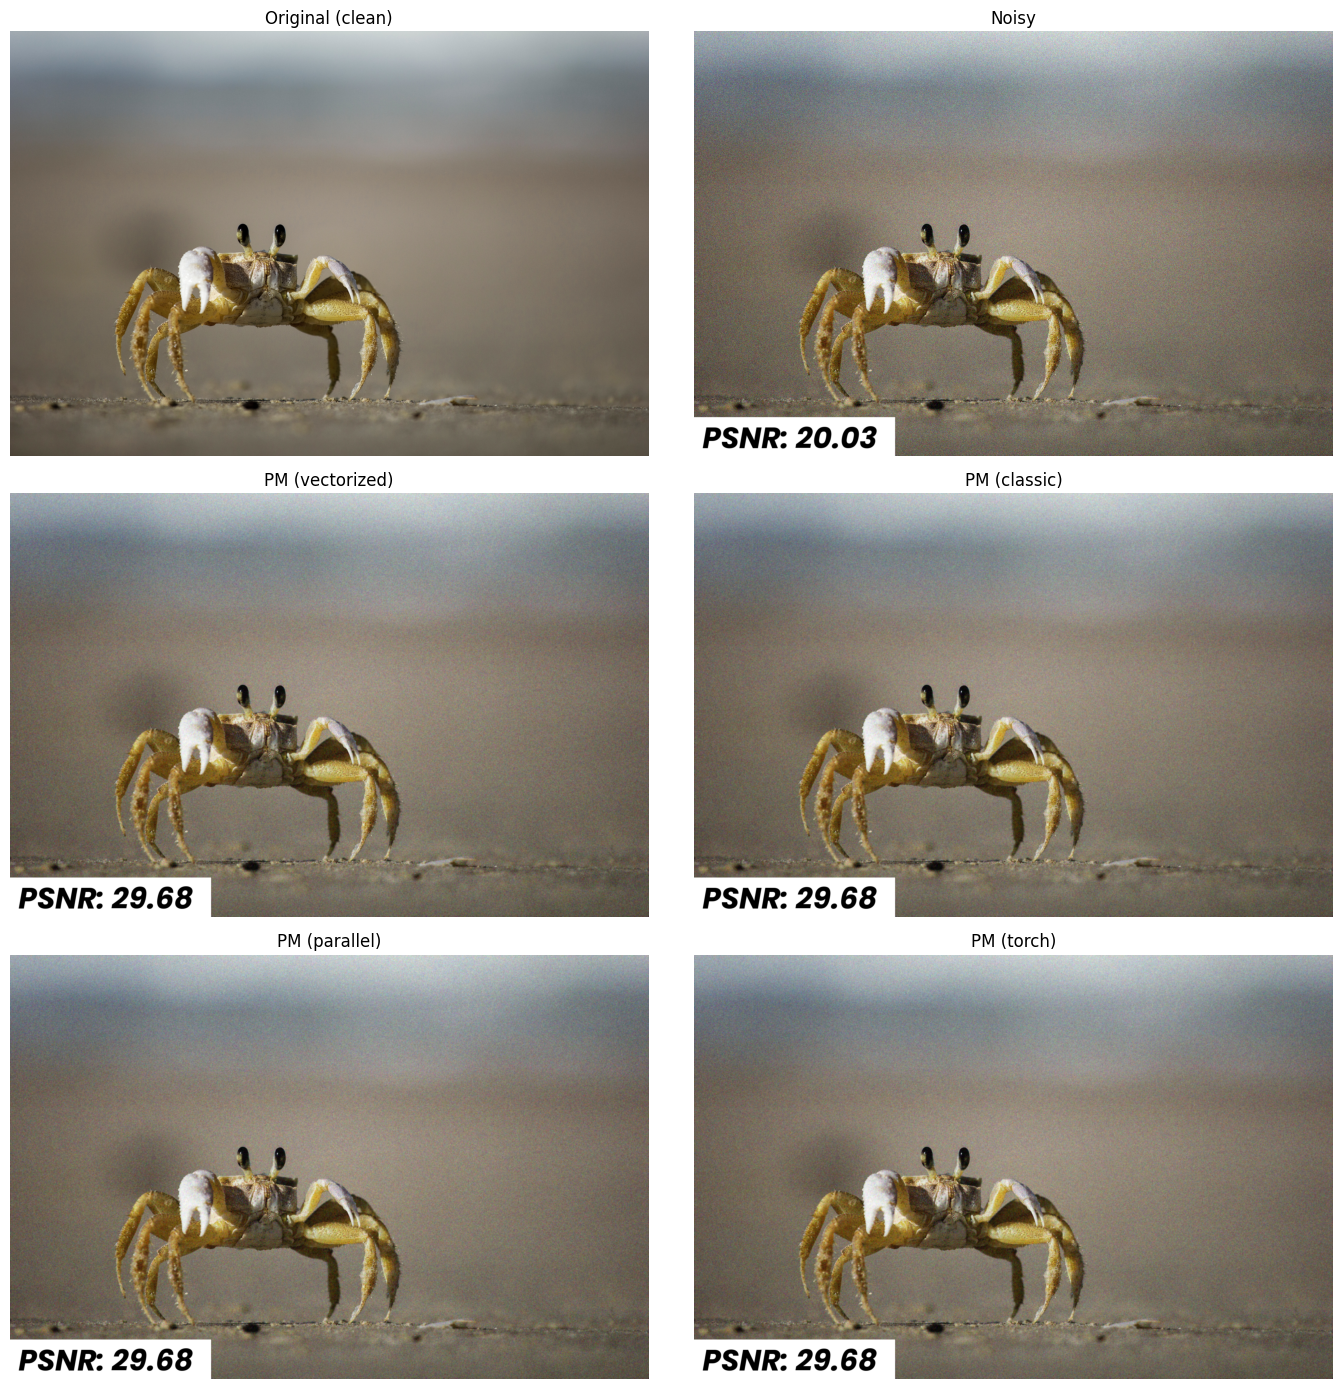

In [7]:
cmap = "inferno"
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

show_plane(axes[0,0], image,                title="Original (clean)", cmap=cmap)
show_plane(axes[0,1], noised_wr_metric,         title="Noisy",            cmap=cmap)
show_plane(axes[1,0], vectorized_wr_metric, title="PM (vectorized)",  cmap=cmap)
show_plane(axes[1,1], classic_wr_metric,    title="PM (classic)",     cmap=cmap)
show_plane(axes[2,0], parallel_wr_metric,   title= "PM (parallel)",   cmap=cmap)
show_plane(axes[2,1], torch_wr_metric,      title="PM (torch)",       cmap=cmap)

plt.tight_layout(); plt.show()